In [57]:
from sklearn.datasets import load_wine
import torch
wine = load_wine(as_frame=True)
X = wine.data
# are we missing a step here?
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)
X_tensor = torch.tensor(X_scaled, dtype=torch.float32)


In [58]:
X.shape

(178, 13)

In [59]:


class wine_auto_encoder(torch.nn.Module):
    def __init__(self, input_dim, latent_dim=3):
        super().__init__()
        self.fc1 = torch.nn.Linear(input_dim, 8)
        self.fc2 = torch.nn.Linear(8, latent_dim)
        self.fc3 = torch.nn.Linear(latent_dim, 8)
        self.fc4 = torch.nn.Linear(8, input_dim)
        self.relu = torch.nn.ReLU()

    def forward(self, x):
        # x = self.fc1(x)
        # x = self.relu(x)
        # x = self.fc2(x)
        # x = self.relu(x)
        # x = self.fc3(x)
        # x = self.relu(x)
        # x = self.fc4(x)
        x = self.encode(x)
        x = self.decode(x)
        return x

    def encode(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

    def decode(self, x):
        x = self.fc3(x)
        x = self.relu(x)
        x = self.fc4(x)
        return x

model = wine_auto_encoder(input_dim=X.shape[1], latent_dim=2)
# reconstruction loss
criterion = torch.nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.003)
losses = []
for epoch in range(2501):
    optimizer.zero_grad()
    
    X_reconstructed = model(X_tensor)
    loss = criterion(X_reconstructed, X_tensor)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())
    if epoch % 100 == 0:
        print(f'Epoch {epoch}, Loss: {loss.item()}')

   

Epoch 0, Loss: 1.0775147676467896
Epoch 100, Loss: 0.5464869141578674
Epoch 200, Loss: 0.3929497003555298
Epoch 300, Loss: 0.3597961366176605
Epoch 400, Loss: 0.3486659526824951
Epoch 500, Loss: 0.34237340092658997
Epoch 600, Loss: 0.3379322290420532
Epoch 700, Loss: 0.333808958530426
Epoch 800, Loss: 0.3303320109844208
Epoch 900, Loss: 0.3269701302051544
Epoch 1000, Loss: 0.3244294226169586
Epoch 1100, Loss: 0.3224778473377228
Epoch 1200, Loss: 0.3208775520324707
Epoch 1300, Loss: 0.31953316926956177
Epoch 1400, Loss: 0.3183416426181793
Epoch 1500, Loss: 0.31715819239616394
Epoch 1600, Loss: 0.31617221236228943
Epoch 1700, Loss: 0.31528329849243164
Epoch 1800, Loss: 0.3145240247249603
Epoch 1900, Loss: 0.31372520327568054
Epoch 2000, Loss: 0.3131462037563324
Epoch 2100, Loss: 0.31274282932281494
Epoch 2200, Loss: 0.31242454051971436
Epoch 2300, Loss: 0.31214308738708496
Epoch 2400, Loss: 0.31191158294677734
Epoch 2500, Loss: 0.31179842352867126


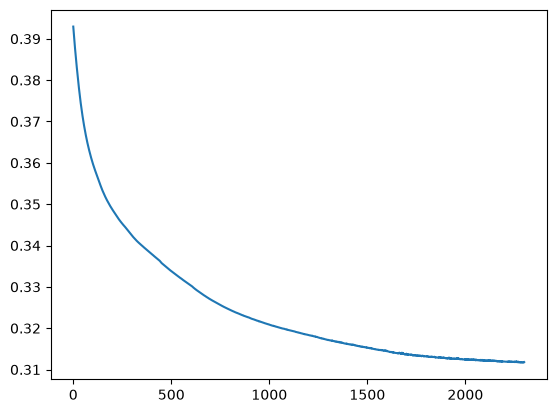

In [60]:
import matplotlib.pyplot as plt
plt.plot(losses[200:])

In [61]:
import pandas as pd
original = X_scaled[0]

reconstructed = model.decode(
    model.encode(
        torch.tensor(X_scaled[0:1], dtype=torch.float32)
    )
).detach().numpy()[0]

comparison = pd.DataFrame({
    "Original": original,
    "Reconstructed": reconstructed
}, index=X.columns)

comparison

,Original,Reconstructed
alcohol,1.518613,1.279605
malic_acid,-0.562250,-0.395950
ash,0.232053,0.086387
alcalinity_of_ash,-1.169593,-1.096019
magnesium,1.913905,0.531717
total_phenols,0.808997,0.957180
flavanoids,1.034819,1.030304
nonflavanoid_phenols,-0.659563,-0.699597
proanthocyanins,1.224884,0.595991
color_intensity,0.251717,0.413370


In [62]:
# rescale to original scale
original = X.iloc[0]
reconstructed = scaler.inverse_transform(reconstructed.reshape(1, -1)).flatten()

comparison = pd.DataFrame({
    "Original": original,
    "Reconstructed": reconstructed
}, index=X.columns)

comparison


,Original,Reconstructed
alcohol,14.23,14.036512
malic_acid,1.71,1.895259
ash,2.43,2.390150
alcalinity_of_ash,15.60,15.845016
magnesium,127.00,107.314445
total_phenols,2.80,2.892479
flavanoids,3.06,3.055503
nonflavanoid_phenols,0.28,0.275032
proanthocyanins,2.29,1.931060
color_intensity,5.64,6.013703


a 2-dimensional representation from which the 13-dimensional input can be reconstructed.

The class separation is an emergent property of that representation.

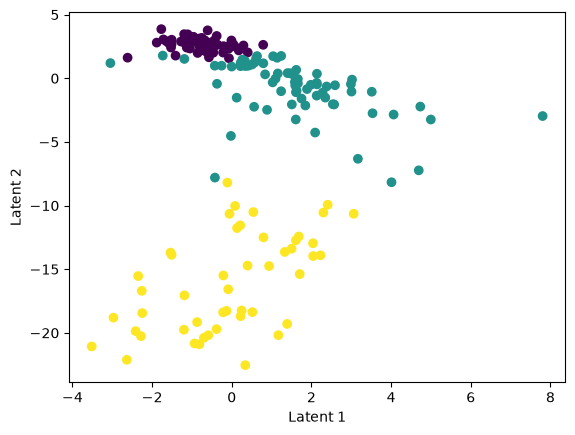

In [63]:
with torch.no_grad():
    Z = model.encode(X_tensor).numpy()

plt.scatter(Z[:, 0], Z[:, 1], c=wine.target)
plt.xlabel("Latent 1")
plt.ylabel("Latent 2")
plt.show()

In [64]:
model.eval()
model.encode(X_tensor[5:6])

tensor([[-1.1067,  3.4564]], grad_fn=<AddmmBackward0>)

In [65]:
model.decode(torch.tensor([[4.8938, 9.8362]]))

tensor([[  7.5339,  -6.6031, -10.2735, -14.6913,   1.2063,   2.1978,   1.4837,
          -4.3988,   3.0682,   4.1910,   1.9138,  -0.6414,   8.5821]],
       grad_fn=<AddmmBackward0>)

In [66]:
X_tensor[5:6]

tensor([[ 1.4816, -0.5174,  0.3052, -1.2897,  0.8607,  1.5621,  1.3661, -0.1761,
          0.6642,  0.7319,  0.4061,  0.3366,  2.2390]])

Text(0.5, 1.0, 'PCA of Wine Dataset')

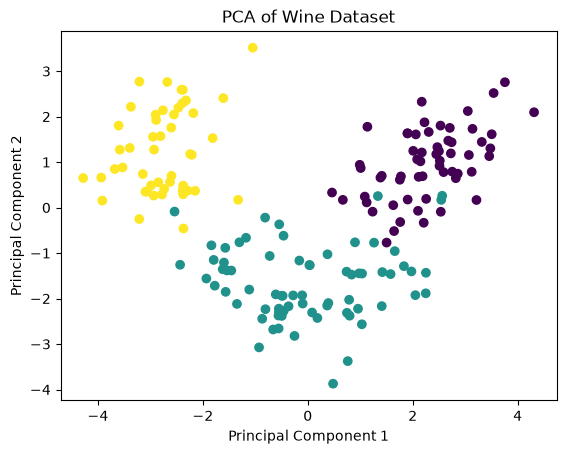

In [67]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=wine.target)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of Wine Dataset')
# plt.colorbar()
